<a href="https://colab.research.google.com/github/aryaraut13/100-days-of-aiml/blob/main/phase1-foundations/day12_linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train size : (16512, 8)
Test size  : (4128, 8)
R² Score   : 0.5758
RMSE       : 0.7456


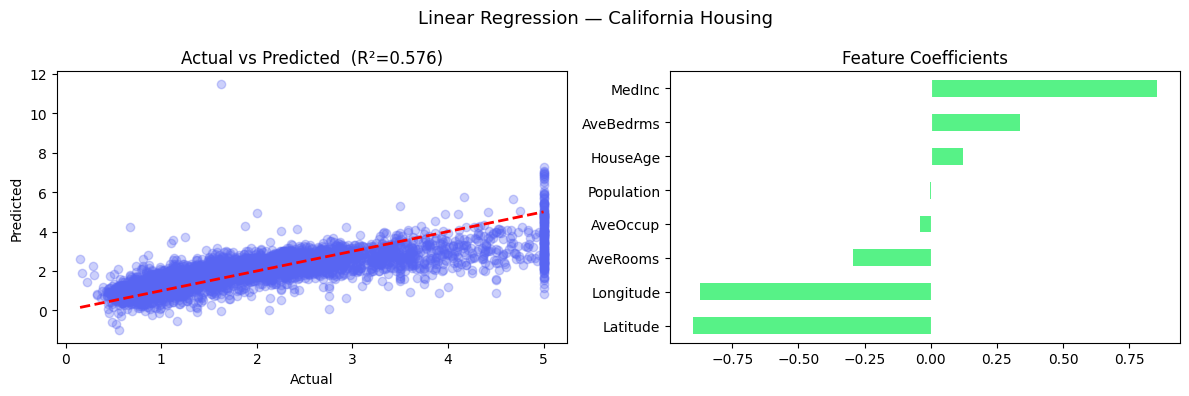

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"R² Score   : {r2:.4f}")
print(f"RMSE       : {rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Linear Regression — California Housing", fontsize=13)

axes[0].scatter(y_test, y_pred, alpha=0.3, color="#5865F2")
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted  (R²={r2:.3f})")

coef_df = pd.Series(model.coef_, index=X.columns).sort_values()
coef_df.plot(kind="barh", ax=axes[1], color="#57F287")
axes[1].set_title("Feature Coefficients")
axes[1].axvline(0, color="white", lw=0.8)

plt.tight_layout()
plt.savefig("day12_linear_regression.png", dpi=150)
plt.show()